# CMA-ES ile SVM Hiperparametre Optimizasyonu (Wine Quality)

Bu notebook'ta **CMA-ES** (Covariance Matrix Adaptation Evolution Strategy) algoritması, Kırmızı Şarap Kalitesi veri seti üzerinde SVM sınıflandırıcısının hiperparametrelerini optimize etmek için kullanılmaktadır.

**Orijinal tutorial:** CMA-ES'in Rosenbrock/Rastrigin fonksiyonları üzerindeki çalışmasını öğretir.

**Bu adaptasyon:** CMA-ES'i gerçek bir makine öğrenmesi problemine uygular — SVM'nin `C` ve `gamma` hiperparametrelerini çapraz doğrulamaaccuracy üzerinden optimize eder.

**Veri Seti:** [Wine Quality (UCI)](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)

In [1]:
# pip kurulumları
!pip install -q kaggle pandas numpy scikit-learn matplotlib seaborn cma

# Gerekli kütüphaneler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Kütüphaneler başarıyla yüklendi!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 6.8 MB/s eta 0:00:00
Kütüphaneler başarıyla yüklendi!


## 1. Veri Setini İndirme

Kaggle API kullanarak Wine Quality veri setini indiriyoruz. Bu veri seti Portekiz'deki "Vinho Verde" şaraplarının fiziksel ve duyusal özelliklerini içermektedir.

**Özellikler:** asitlik, çökelti, asidiklik, şeker, tuz, sülfür dioksit, yoğunluk, sülfat, alkol

**Hedef:** şarap kalitesi (0-10 arası puan)

In [2]:
# Kaggle API ile veri setini indirme
# NOT: Kaggle API anahtarınızın ~/.kaggle/kaggle.json dosyasında olması gerekir
# Alternatif olarak manuel yükleme yapılabilir

import subprocess
import zipfile

# Kaggle dizinini kontrol et
kaggle_dir = os.path.expanduser('~/.kaggle')
if not os.path.exists(kaggle_dir):
    os.makedirs(kaggle_dir)
    print('Kaggle dizini oluşturuldu. Lütfen kaggle.json dosyasını bu dizine koyun.')

# Veri setini indirme
dataset_name = 'uciml/red-wine-quality-cortez-et-al-2009'
download_dir = './wine_data'

if not os.path.exists(download_dir):
    os.makedirs(download_dir)

try:
    # Kaggle ile indirme
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', dataset_name, '-p', download_dir, '--unzip'],
        capture_output=True, text=True, check=True
    )
    print('Veri seti Kaggle ile başarıyla indirildi!')
except (subprocess.CalledProcessError, FileNotFoundError):
    print('Kaggle CLI bulunamadı veya indirme başarısız. Manuel yükleme deneniyor...')
    # Alternatif: doğrudan URL'den indirme
    try:
        import urllib.request
        url = 'https://raw.githubusercontent.com/apoddar573/Machine-Learning-Course-Projects/master/Wine%20Quality/winequality-red.csv'
        filepath = os.path.join(download_dir, 'winequality-red.csv')
        urllib.request.urlretrieve(url, filepath)
        print('Veri seti doğrudan URL ile indirildi!')
    except Exception as e:
        print(f'İndirme hatası: {e}')

# Veri setini yükleme
csv_files = [f for f in os.listdir(download_dir) if f.endswith('.csv')]
if csv_files:
    csv_path = os.path.join(download_dir, csv_files[0])
    df = pd.read_csv(csv_path, sep=';' if csv_files[0] != 'winequality-red.csv' else ',')
    print(f'\nVeri seti yüklendi: {csv_path}')
else:
    raise FileNotFoundError('CSV dosyası bulunamadı!')

print(f'Boyut: {df.shape}')
print(f'\nİlk 5 satır:')
df.head()

Kaggle dizini oluşturuldu. Lütfen kaggle.json dosyasını bu dizine koyun.
Veri seti Kaggle ile başarıyla indirildi!

Veri seti yüklendi: ./wine_data/winequality-red.csv
Boyut: (1599, 12)

İlk 5 satır:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Veri Analizi

Veri setinin temel istatistiklerini ve dağılımlarını inceleyelim. Quality dağılımı ve özellikler arası korelasyonları görselleştireceğiz.

VERİ SETİ BİLGİLERİ
Satır sayısı: 1599
Sütun sayısı: 12

Eksik değer sayısı:
0

Sütunlar: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

İSTATİSTİKSEL ÖZET


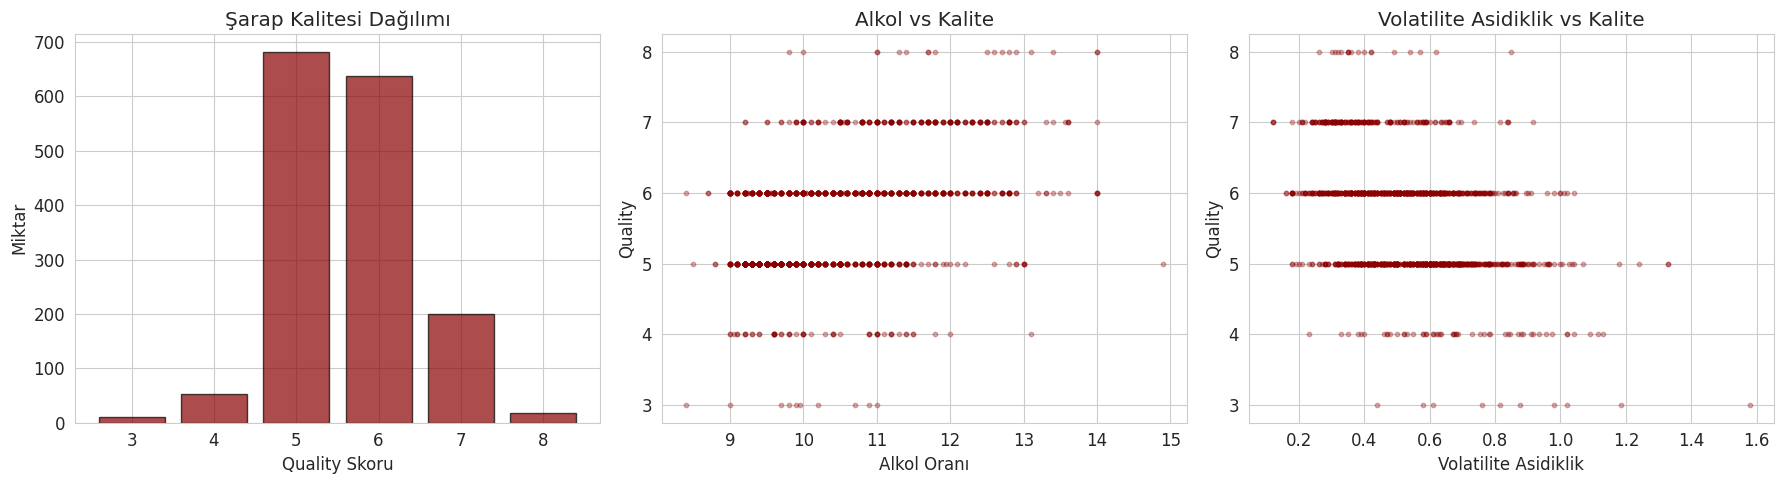

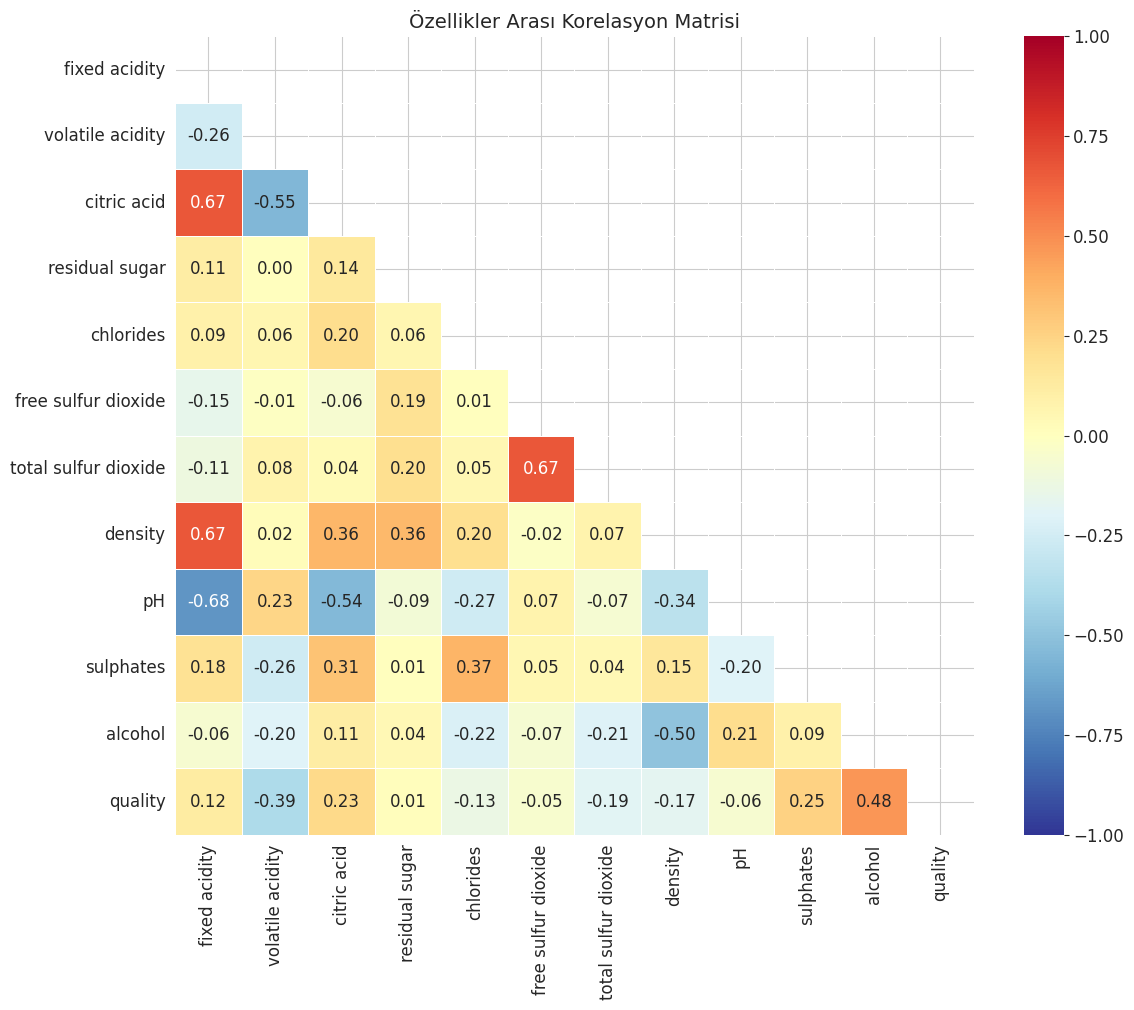


Quality değerleri: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Quality dağılımı:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [3]:
# Temel bilgiler
print('='*60)
print('VERİ SETİ BİLGİLERİ')
print('='*60)
print(f'Satır sayısı: {df.shape[0]}')
print(f'Sütun sayısı: {df.shape[1]}')
print(f'\nEksik değer sayısı:\n{df.isnull().sum().sum()}')
print(f'\nSütunlar: {list(df.columns)}')

print(f'\n{"="*60}')
print('İSTATİSTİKSEL ÖZET')
print('='*60)
df.describe()

# Quality dağılımı
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Quality dağılımı
quality_counts = df['quality'].value_counts().sort_index()
axes[0].bar(quality_counts.index, quality_counts.values, color='darkred', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Quality Skoru')
axes[0].set_ylabel('Miktar')
axes[0].set_title('Şarap Kalitesi Dağılımı')
axes[0].set_xticks(quality_counts.index)

# Alkol vs Quality
axes[1].scatter(df['alcohol'], df['quality'], alpha=0.3, c='darkred', s=10)
axes[1].set_xlabel('Alkol Oranı')
axes[1].set_ylabel('Quality')
axes[1].set_title('Alkol vs Kalite')

# Volatilite asitlik vs Quality
axes[2].scatter(df['volatile acidity'], df['quality'], alpha=0.3, c='darkred', s=10)
axes[2].set_xlabel('Volatilite Asidiklik')
axes[2].set_ylabel('Quality')
axes[2].set_title('Volatilite Asidiklik vs Kalite')

plt.tight_layout()
plt.show()

# Korelasyon matrisi
fig, ax = plt.subplots(figsize=(12, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Özellikler Arası Korelasyon Matrisi', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nQuality değerleri: {sorted(df["quality"].unique())}')
print(f'Quality dağılımı:\n{df["quality"].value_counts().sort_index()}')

## 3. CMA-ES Teorisi

### Covariance Matrix Adaptation Evolution Strategy (CMA-ES)

CMA-ES, türev kullanmayan (derivative-free) optimizasyon yöntemlerinden biridir ve özellikle zorlu, çok modlu, gürültülü optimizasyon problemlerinde etkilidir.

### Temel Fikir

1. **Arama Dağılımı:** Her nesilde, aday çözümler bir Gauss dağılımından örneklendirilir:
   $$x_k \sim \mathcal{N}(m, \sigma^2 C)$$
   - $m$: dağılımın ortalaması (en iyi bilinen çözüm)
   - $\sigma$: adım boyutu (çekirdek skalası)
   - $C$: kovaryans matrisi (arama yönlerini belirler)

2. **Cholesky Örnekleme:** Kovaryans matrisi $C = LL^T$ şeklinde Cholesky ayrıştırmasına tabi tutulur. Örnekleme:
   $$x_k = m + \sigma L z_k, \quad z_k \sim \mathcal{N}(0, I)$$

3. **Covariance Matrix Adaptation (Kovaryans Matrisi Uyumlaması):**
   - En iyi $\lambda$ çözüm seçilir (seçim baskınlığı)
   - Kovaryans matrisi bu çözümlerin yönlerine göre güncellenir:
   $$C_{t+1} = (1-c_1)C_t + c_1 \frac{p_\sigma p_\sigma^T}{\|p_\sigma\|^2} \quad \text{(rank-1 güncelleme)}$$
   $$C_{t+1} = (1-c_\mu)C_t + c_\mu \sum_{i=1}^{\mu} w_i y_{i:\lambda} y_{i:\lambda}^T \quad \text{(rank-}\mu\text{ güncelleme)}$$

4. **Adım Boyutu Adaptasyonu (CSA - Cumulative Step-size Adaptation):**
   - Evrim yolu $p_\sigma$ takip edilir:
   $$p_\sigma \leftarrow (1-c_\sigma) p_\sigma + \sqrt{c_\sigma(2-c_\sigma)\mu_{\text{eff}}} C^{-1/2} \bar{y}$$
   - $\sigma$ bu yola göre büyütülür veya küçültülür

### CMA-ES'in Güçlü Yönleri

- **Yön Adaptasyonu:** Kovaryans matrisi, fonksiyonun topolojisine uyum sağlar
- **Adım Boyutu Adaptasyonu:** Arama ölçeği otomatik ayarlanır
- **Türev Gerektirmez:** Sadece fonksiyon değerleriyle çalışır
- **Yüksek Boyutlu Problemlerde Etkili:** 100+ boyutta bile performans korunur

## 4. CMA-ES Implementasyonu

Aşağıda CMA-ES algoritmasını sıfırdan implemente ediyoruz. Bu implementasyon şunları içerir:

- Cholesky örnekleme
- CSA (Cumulative Step-size Adaptation)
- Rank-1 ve rank-μ kovaryans matrisi güncellemeleri
- Adım boyutu sigma adaptasyonu

In [4]:
class CMAES:
    """
    Covariance Matrix Adaptation Evolution Strategy (CMA-ES)

    Sıfırdan implemente edilmiş CMA-ES algoritması.
    """

    def __init__(self, fitness_func, dim, bounds=None, sigma0=0.5,
                 pop_size=None, elite_ratio=0.25, max_generations=200,
                 tol=1e-8, verbose=True, seed=42):
        """
        Parametreler:
        -----------
        fitness_func : callable
            Hedef fonksiyon (minimize edilecek)
        dim : int
            Problem boyutu
        bounds : tuple veya None
            (lower, upper) sınırları, None ise sınırsız
        sigma0 : float
            Başlangıç adım boyutu
        pop_size : int veya None
            Popülasyon büyüklüğü, None ise otomatik
        elite_ratio : float
            En iyi bireylerin oranı (seçim baskınlığı)
        max_generations : int
            Maksimum nesil sayısı
        tol : float
            Yakınsama toleransı
        verbose : bool
            Konsol çıktısı
        seed : int
            Rastgele tohum
        """
        self.fitness_func = fitness_func
        self.dim = dim
        self.bounds = bounds
        self.sigma = sigma0
        self.max_generations = max_generations
        self.tol = tol
        self.verbose = verbose

        np.random.seed(seed)

        # Popülasyon büyüklüğü ve seçim
        if pop_size is None:
            self.pop_size = 4 + int(3 * np.log(dim))
        else:
            self.pop_size = pop_size

        self.mu = max(2, int(self.pop_size * elite_ratio))  # Seçilen birey sayısı

        # Ağırlıklar (seçim baskınlığı)
        self.weights = np.log(self.mu + 0.5) - np.log(np.arange(1, self.mu + 1))
        self.weights = self.weights / np.sum(self.weights)
        self.mu_eff = 1.0 / np.sum(self.weights ** 2)  # Efektif popülasyon büyüklüğü

        # CSA parametreleri
        self.c_sigma = (self.mu_eff + 2) / (dim + self.mu_eff + 5)
        self.d_sigma = 1 + 2 * max(0, np.sqrt((self.mu_eff - 1) / (dim + 1)) - 1) + self.c_sigma

        # Covariance matrix güncelleme parametreleri
        self.c_c = (4 + self.mu_eff / dim) / (dim + 4 + 2 * self.mu_eff / dim)
        self.c_1 = 2 / ((dim + 1.3) ** 2 + self.mu_eff)
        self.c_mu = min(1 - self.c_1,
                        2 * (self.mu_eff - 2 + 1 / self.mu_eff) / ((dim + 2) ** 2 + self.mu_eff))

        # Başlangıç değerleri
        self.mean = np.zeros(dim)  # Ortalama
        self.C = np.eye(dim)       # Kovaryans matrisi
        self.p_sigma = np.zeros(dim)  # Evrim yolu (sigma)
        self.p_c = np.zeros(dim)      # Evrim yolu (covariance)

        # Cholesky matrisi
        self.B = np.eye(dim)  # Özvektörler
        self.D = np.ones(dim)  # Özdeğerler
        self.L = np.eye(dim)  # Cholesky ayrıştırması

        # Geçmiş
        self.history = {
            'best_fitness': [],
            'mean_fitness': [],
            'sigma': [],
            'best_solution': [],
            'cond_number': []
        }

        self.best_fitness = np.inf
        self.best_solution = None

    def _update_cholesky(self):
        """Kovaryans matrisinin Cholesky ayrıştırmasını güncelle."""
        # Kovaryans matrisini simetrik yap
        self.C = (self.C + self.C.T) / 2

        try:
            # Özdeğer ayrıştırması
            eigenvalues, eigenvectors = np.linalg.eigh(self.C)

            # Negatif özdeğerleri düzelt
            eigenvalues = np.maximum(eigenvalues, 1e-20)

            # Sırala (büyükten küçüğe)
            idx = np.argsort(eigenvalues)[::-1]
            eigenvalues = eigenvalues[idx]
            eigenvectors = eigenvectors[:, idx]

            self.D = np.sqrt(eigenvalues)
            self.B = eigenvectors
            self.L = self.B @ np.diag(self.D)
        except np.linalg.LinAlgError:
            # Cholesky başarısız olursa, birim matris kullan
            self.L = np.eye(self.dim)
            self.D = np.ones(self.dim)
            self.B = np.eye(self.dim)

    def _sample_population(self):
        """Cholesky örnekleme ile popülasyon oluştur."""
        z = np.random.randn(self.pop_size, self.dim)
        # x = mean + sigma * L * z
        y = z @ self.L.T  # L z çarpımı
        x = self.mean + self.sigma * y
        return x, y, z

    def _clip_to_bounds(self, x):
        """Çözümleri sınırlara kırp."""
        if self.bounds is not None:
            lower, upper = self.bounds
            x = np.clip(x, lower, upper)
        return x

    def _adapt_covariance_matrix(self, y_w):
        """Kovaryans matrisini güncelle (rank-1 + rank-μ)."""
        # Rank-1 güncelleme
        self.p_c = (1 - self.c_c) * self.p_c + \
                   np.sqrt(self.c_c * (2 - self.c_c) * self.mu_eff) * \
                   (self.B @ (self.p_sigma / self.D))

        h_sigma = (np.linalg.norm(self.p_sigma) /
                   np.sqrt(1 - (1 - self.c_sigma) ** (2 * (self.generation + 1))) /
                   np.sqrt(self.dim) < 1.4 + 2 / (self.dim + 1))

        # Covariance matrix güncelleme
        rank_one = np.outer(self.p_c, self.p_c)

        # Rank-μ güncelleme
        y_sorted = np.array([y_w[i] for i in range(self.mu)])
        rank_mu = sum(self.weights[i] * np.outer(y_sorted[i], y_sorted[i])
                     for i in range(self.mu))

        # Birleşik güncelleme
        self.C = (1 - self.c_1 - self.c_mu) * self.C + \
                 self.c_1 * rank_one + \
                 self.c_mu * rank_mu

        # Pozitif tanımlı olduğundan emin ol
        min_eig = np.min(np.linalg.eigvalsh(self.C))
        if min_eig < 1e-20:
            self.C += (1e-20 - min_eig) * np.eye(self.dim)

    def _adapt_step_size(self, y_w):
        """Adım boyutunu (sigma) CSA ile adapt et."""
        # Evrim yolunu güncelle
        self.p_sigma = (1 - self.c_sigma) * self.p_sigma + \
                       np.sqrt(self.c_sigma * (2 - self.c_sigma) * self.mu_eff) * \
                       (self.B @ (self.p_sigma / self.D))

        # Sigma güncelleme
        expected_norm = np.sqrt(self.dim) * (1 - 1 / (4 * self.dim) +
                                            1 / (21 * self.dim ** 2))
        self.sigma *= np.exp((self.c_sigma / self.d_sigma) *
                            (np.linalg.norm(self.p_sigma) / expected_norm - 1))

    def optimize(self):
        """CMA-ES optimizasyonunu çalıştır."""
        if self.verbose:
            print(f'CMA-ES Başlatılıyor...')
            print(f'  Problem boyutu: {self.dim}')
            print(f'  Popülasyon: {self.pop_size}')
            print(f'  Seçilen birey: {self.mu}')
            print(f'  Başlangıç sigma: {self.sigma:.4f}')
            print(f'  Maksimum nesil: {self.max_generations}')
            print('-' * 50)

        self.generation = 0
        stagnant_count = 0

        while self.generation < self.max_generations:
            # Popülasyon örnekle
            x, y, z = self._sample_population()

            # Sınırlara kırp
            x = self._clip_to_bounds(x)

            # Uygunluk değerlendir
            fitness = np.array([self.fitness_func(ind) for ind in x])

            # Sırala ve en iyi μ'yi seç
            sorted_idx = np.argsort(fitness)
            elite_idx = sorted_idx[:self.mu]

            # En iyi çözümü güncelle
            if fitness[sorted_idx[0]] < self.best_fitness:
                self.best_fitness = fitness[sorted_idx[0]]
                self.best_solution = x[sorted_idx[0]].copy()
                stagnant_count = 0
            else:
                stagnant_count += 1

            # Ağırlıklı ortalama (seçim baskınlığı)
            y_w = y[elite_idx]  # Seçilen bireylerin y değerleri
            x_w = np.sum(self.weights[:, np.newaxis] * x[elite_idx], axis=0)

            # Ortaortalama güncelleme
            self.mean = x_w

            # Covariance matrix ve sigma güncelleme
            self._adapt_step_size(y_w)
            self._adapt_covariance_matrix(y_w)

            # Cholesky güncelleme
            self._update_cholesky()

            # Geçmiş kaydı
            mean_fit = np.mean(fitness)
            self.history['best_fitness'].append(self.best_fitness)
            self.history['mean_fitness'].append(mean_fit)
            self.history['sigma'].append(self.sigma)
            self.history['best_solution'].append(self.best_solution.copy())

            # Koşul sayısı
            eigvals = np.linalg.eigvalsh(self.C)
            eigvals = np.maximum(eigvals, 1e-20)
            cond = np.max(eigvals) / np.min(eigvals)
            self.history['cond_number'].append(cond)

            # İlerleme raporu
            if self.verbose and (self.generation % 10 == 0 or
                                 self.generation == self.max_generations - 1):
                print(f'Nesil {self.generation:4d} | '
                      f'En İyi: {self.best_fitness:.6f} | '
                      f'Ortalama: {mean_fit:.6f} | '
                      f'Sigma: {self.sigma:.6f} | '
                      f'Koşul: {cond:.2f}')

            # Yakınsama kontrolü
            if self.sigma < self.tol:
                if self.verbose:
                    print(f'\nSigma tolerans altında ({self.sigma:.2e} < {self.tol}). Yakınsandı!')
                break

            if stagnant_count > 30:
                if self.verbose:
                    print(f'\n30 nesildir iyileşme yok. Duraklatılıyor.')
                break

            self.generation += 1

        if self.verbose:
            print(f'\nOptimizasyon tamamlandı! Toplam {self.generation + 1} nesil.')
            print(f'En iyi uygunluk: {self.best_fitness:.6f}')

        return self.best_solution, self.best_fitness

print('CMA-ES sınıfı tanımlandı!')

CMA-ES sınıfı tanımlandı!


## 5. Hedef Fonksiyonu: SVM Doğruluk

CMA-ES'in optimize edeceği hedef fonksiyon, SVM sınıflandırıcısının çapraz doğrulamaaccuracy'ıdır.

**Parametreler:**
- `C`: Düzenleme parametresi (logaritmik ölçekte: $10^{-2}$ ile $10^{4}$ arası)
- `gamma`: Çekirdek katsayısı (logaritmik ölçekte: $10^{-5}$ ile $10^{1}$ arası)

CMA-ES bu iki parametreyi optimize ederek en yüksek doğruluğu bulmaya çalışır.

In [5]:
# Veri hazırlığı
# Quality'yi kategorilere ayır: düşük (3-4), orta (5-6), yüksek (7-8)
df['quality_label'] = pd.cut(df['quality'], bins=[0, 4, 6, 10],
                              labels=['Düşük', 'Orta', 'Yüksek'])

# Özellikler ve hedef
feature_cols = [c for c in df.columns if c not in ['quality', 'quality_label']]
X = df[feature_cols].values
y = df['quality_label'].values

# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Veriyi böl
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Eğitim seti: {X_train_scaled.shape}')
print(f'Test seti: {X_test_scaled.shape}')
print(f'Sınıf dağılımı (eğitim): {np.bincount(y_train)}')

# Hedef fonksiyon tanımı
def svm_fitness(params):
    """
    SVM hiperparametreleri için hedef fonksiyon.

    params[0] = C (logaritmik ölçekte)
    params[1] = gamma (logaritmik ölçekte)

    Negatif doğruluk döndürür (CMA-ES minimize ettiği için).
    """
    # Logaritmik ölçekteki parametreleri doğrusal ölçeğe çevir
    C = 10 ** params[0]       # 10^-2 ile 10^4 arası
    gamma = 10 ** params[1]   # 10^-5 ile 10^1 arası

    # Parametre sınırları kontrolü
    if C < 1e-3 or C > 1e5:
        return 0.0  # Kötü çözüm
    if gamma < 1e-6 or gamma > 1e2:
        return 0.0

    try:
        svm = SVC(
            C=C,
            gamma=gamma,
            kernel='rbf',
            random_state=42,
            max_iter=5000
        )

        # 3 katlı çapraz doğrulama
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(svm, X_train_scaled, y_train,
                                 cv=cv, scoring='accuracy', n_jobs=-1)

        # Negatif doğruluk (minimize)
        return -np.mean(scores)
    except Exception:
        return 0.0  # Hata durumunda

# CMA-ES parametre aralıkları
# C: 10^-2 ile 10^4 (logaritmik)
# gamma: 10^-5 ile 10^1 (logaritmik)
param_bounds = np.array([[-2, 4], [-5, 1]])

print(f'\nHedef fonksiyon tanmlandı.')
print(f'C aralığı: [10^(-2), 10^4] = [0.01, 10000]')
print(f'gamma aralığı: [10^(-5), 10^1] = [0.00001, 10]')

# Test fonksiyonu
test_params = np.array([0.0, 0.0])  # C=1, gamma=1
print(f'\nTest (C=1, gamma=1): negatif doğruluk = {svm_fitness(test_params):.4f}')

Eğitim seti: (1279, 11)
Test seti: (320, 11)
Sınıf dağılımı (eğitim): [  50 1055  174]

Hedef fonksiyon tanmlandı.
C aralığı: [10^(-2), 10^4] = [0.01, 10000]
gamma aralığı: [10^(-5), 10^1] = [0.00001, 10]

Test (C=1, gamma=1): negatif doğruluk = -0.8585


## 6. Optimizasyonun Çalıştırılması

CMA-ES algoritmasını SVM hiperparametrelerini optimize etmek için çalıştırıyoruz.

**Ayarlar:**
- Başlangıç sigma: 0.5 (logaritmik ölçekte geniş arama)
- Popülasyon: otomatik (problem boyutuna göre)
- Maksimum nesil: 50

CMA-ES Başlatılıyor...
  Problem boyutu: 2
  Popülasyon: 15
  Seçilen birey: 6
  Başlangıç sigma: 1.0000
  Maksimum nesil: 50
--------------------------------------------------
Nesil    0 | En İyi: -0.858479 | Ortalama: -0.835858 | Sigma: 0.706024 | Koşul: 1.27
Nesil   10 | En İyi: -0.864729 | Ortalama: -0.863949 | Sigma: 0.021728 | Koşul: 5.91
Nesil   20 | En İyi: -0.864729 | Ortalama: -0.863949 | Sigma: 0.000669 | Koşul: 2.68
Nesil   30 | En İyi: -0.864729 | Ortalama: -0.863949 | Sigma: 0.000021 | Koşul: 1.04

30 nesildir iyileşme yok. Duraklatılıyor.

Optimizasyon tamamlandı! Toplam 39 nesil.
En iyi uygunluk: -0.864729

Geçen süre: 174.62 saniye

En iyi parametreler:
  C = 9.468313 (10^0.9763)
  gamma = 1.551010 (10^0.1906)
  Çapraz doğrulama accuracy: 0.8647


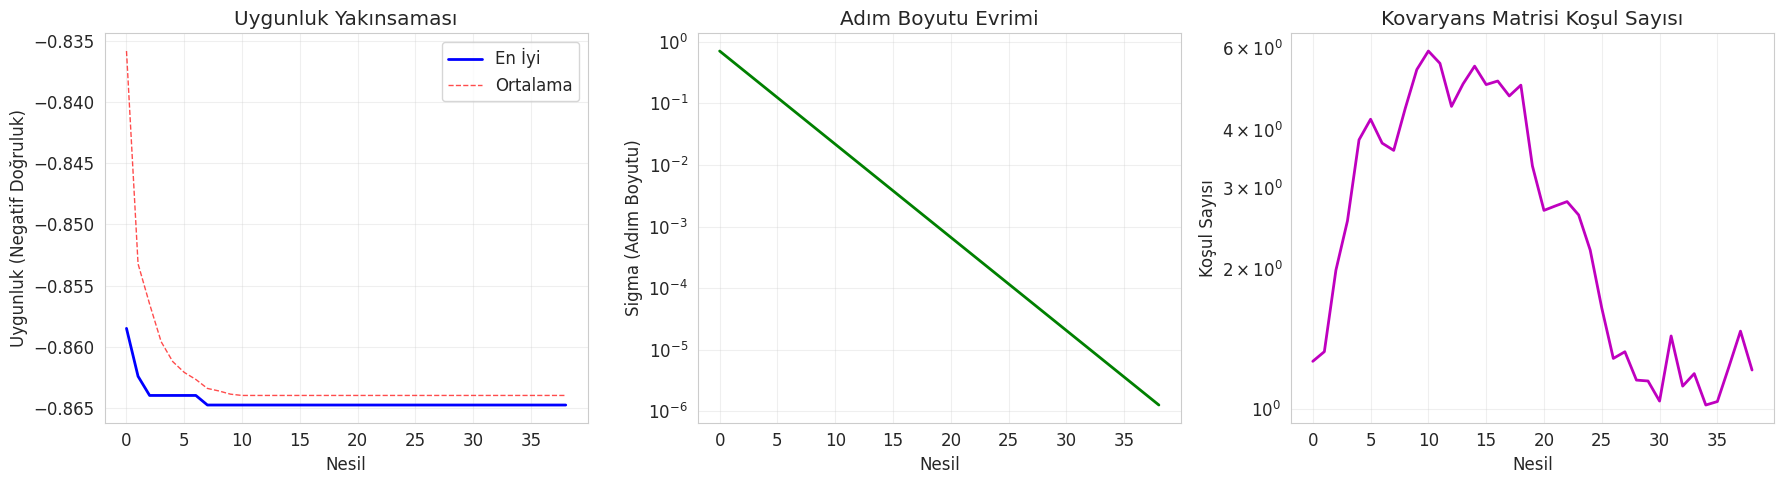

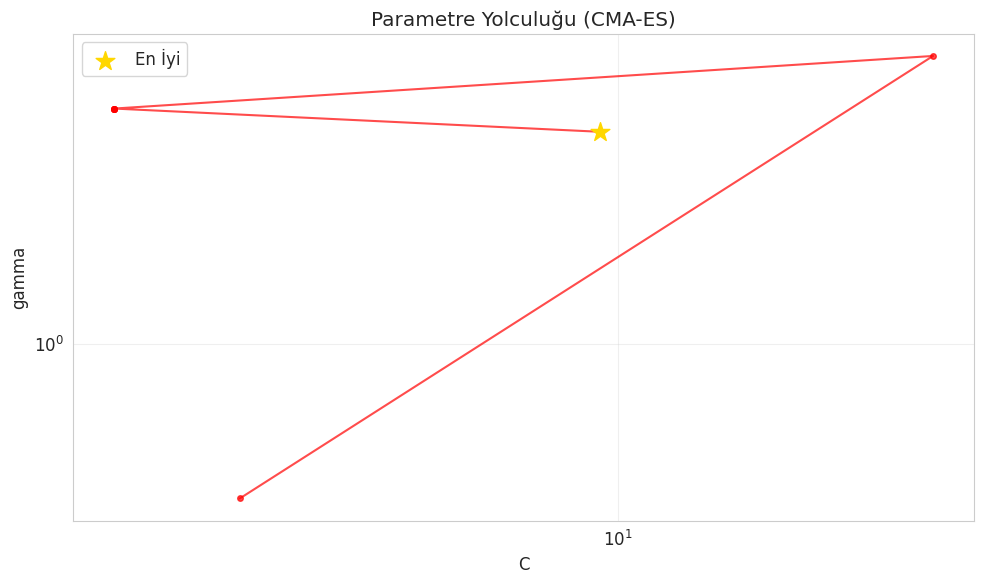

In [6]:
# CMA-ES'i çalıştır
start_time = time.time()

cmaes = CMAES(
    fitness_func=svm_fitness,
    dim=2,
    bounds=(-5, 4),  # Logaritmik ölçekte
    sigma0=1.0,
    pop_size=15,
    elite_ratio=0.4,
    max_generations=50,
    tol=1e-6,
    verbose=True,
    seed=42
)

best_params, best_fitness = cmaes.optimize()

elapsed_time = time.time() - start_time
print(f'\nGeçen süre: {elapsed_time:.2f} saniye')

# Sonuçları göster
best_C = 10 ** best_params[0]
best_gamma = 10 ** best_params[1]
print(f'\nEn iyi parametreler:')
print(f'  C = {best_C:.6f} (10^{best_params[0]:.4f})')
print(f'  gamma = {best_gamma:.6f} (10^{best_params[1]:.4f})')
print(f'  Çapraz doğrulama accuracy: {-best_fitness:.4f}')

# Yakınsama grafiği
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Uygunluk yakınsaması
axes[0].plot(cmaes.history['best_fitness'], 'b-', linewidth=2, label='En İyi')
axes[0].plot(cmaes.history['mean_fitness'], 'r--', linewidth=1, alpha=0.7, label='Ortalama')
axes[0].set_xlabel('Nesil')
axes[0].set_ylabel('Uygunluk (Negatif Doğruluk)')
axes[0].set_title('Uygunluk Yakınsaması')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Sigma evrimi
axes[1].plot(cmaes.history['sigma'], 'g-', linewidth=2)
axes[1].set_xlabel('Nesil')
axes[1].set_ylabel('Sigma (Adım Boyutu)')
axes[1].set_title('Adım Boyutu Evrimi')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

# 3. Koşul sayısı
axes[2].plot(cmaes.history['cond_number'], 'm-', linewidth=2)
axes[2].set_xlabel('Nesil')
axes[2].set_ylabel('Koşul Sayısı')
axes[2].set_title('Kovaryans Matrisi Koşul Sayısı')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Parametre yolculuğu
param_history = np.array(cmaes.history['best_solution'])
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(10 ** param_history[:, 0], 10 ** param_history[:, 1], 'ro-', markersize=4, alpha=0.7)
ax.scatter([best_C], [best_gamma], s=200, c='gold', marker='*', zorder=5, label='En İyi')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('C')
ax.set_ylabel('gamma')
ax.set_title('Parametre Yolculuğu (CMA-ES)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Sonuçların Analizi

CMA-ES ile bulunan en iyi parametreleri test seti üzerinde değerlendiriyoruz ve GridSearch ile karşılaştırıyoruz.

CMA-ES Optimizasyonu Sonuçları:
  Test Accuracy: 0.8625

Sınıflandırma Raporu:
              precision    recall  f1-score   support

       Düşük       0.50      0.08      0.13        13
        Orta       0.87      0.98      0.92       264
      Yüksek       0.77      0.40      0.52        43

    accuracy                           0.86       320
   macro avg       0.71      0.48      0.53       320
weighted avg       0.84      0.86      0.84       320


GridSearchCV Karşılaştırması
GridSearch Sonuçları:
  En iyi parametreler: {'C': 1, 'gamma': 1}
  Test Accuracy: 0.8594
  Geçen süre: 16.90 saniye
  Grid boyutu: 36 kombinasyon

KARŞILAŞTIRMA TABLOSU
      Yöntem  Test Accuracy  Süre (sn) En İyi C En İyi gamma  Değerlendirme Sayısı
      CMA-ES       0.862500 174.624696   9.4683     1.551010                   585
GridSearchCV       0.859375  16.897395        1            1                   108


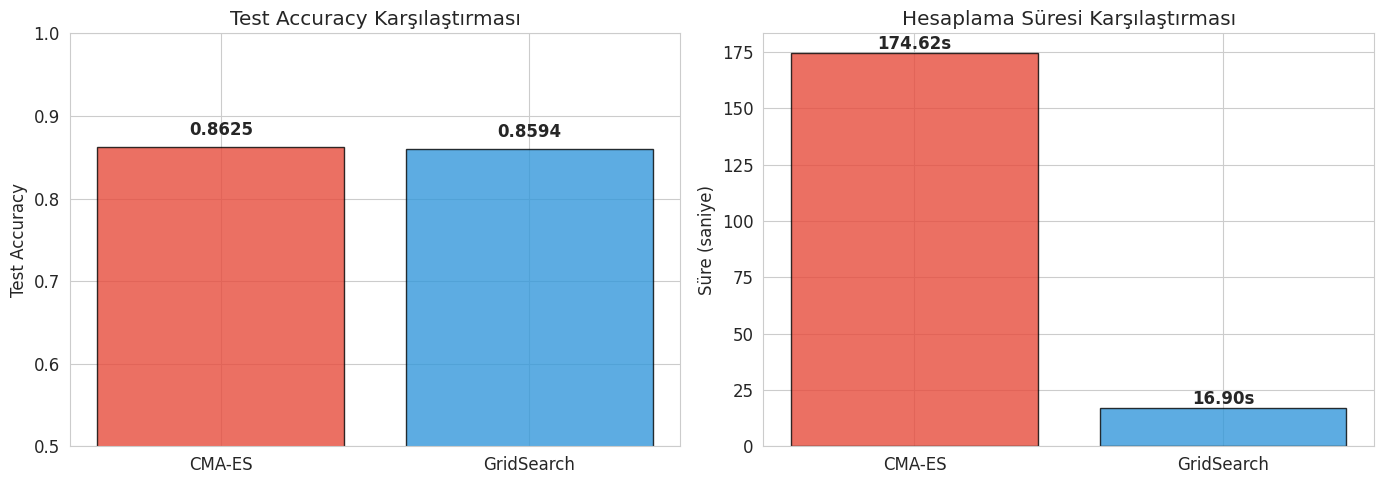

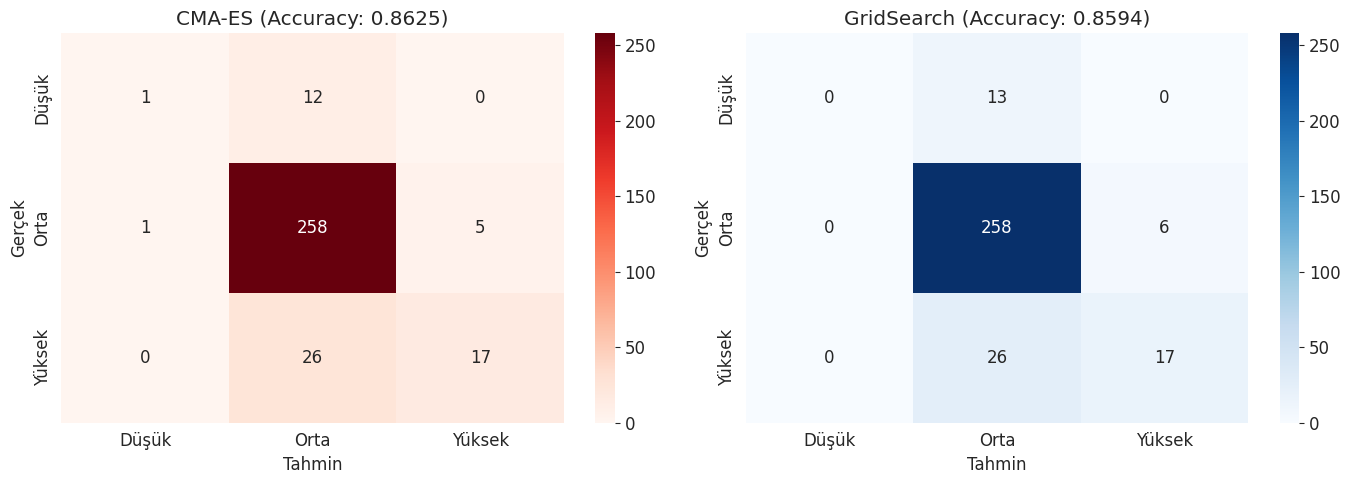

In [7]:
# CMA-ES en iyi parametrelerle test seti performansı
svm_best = SVC(C=best_C, gamma=best_gamma, kernel='rbf', random_state=42)
svm_best.fit(X_train_scaled, y_train)
y_pred_cmaes = svm_best.predict(X_test_scaled)

accuracy_cmaes = accuracy_score(y_test, y_pred_cmaes)
print(f'CMA-ES Optimizasyonu Sonuçları:')
print(f'  Test Accuracy: {accuracy_cmaes:.4f}')
print(f'\nSınıflandırma Raporu:')
print(classification_report(y_test, y_pred_cmaes, target_names=le.classes_))

# GridSearchCV ile karşılaştırma
print('\n' + '='*60)
print('GridSearchCV Karşılaştırması')
print('='*60)

start_time_grid = time.time()

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'gamma': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_scaled, y_train)

grid_time = time.time() - start_time_grid

y_pred_grid = grid_search.predict(X_test_scaled)
accuracy_grid = accuracy_score(y_test, y_pred_grid)

print(f'GridSearch Sonuçları:')
print(f'  En iyi parametreler: {grid_search.best_params_}')
print(f'  Test Accuracy: {accuracy_grid:.4f}')
print(f'  Geçen süre: {grid_time:.2f} saniye')
print(f'  Grid boyutu: {len(param_grid["C"]) * len(param_grid["gamma"])} kombinasyon')

# Karşılaştırma tablosu
print('\n' + '='*60)
print('KARŞILAŞTIRMA TABLOSU')
print('='*60)
comparison = pd.DataFrame({
    'Yöntem': ['CMA-ES', 'GridSearchCV'],
    'Test Accuracy': [accuracy_cmaes, accuracy_grid],
    'Süre (sn)': [elapsed_time, grid_time],
    'En İyi C': [f'{best_C:.4f}', grid_search.best_params_['C']],
    'En İyi gamma': [f'{best_gamma:.6f}', grid_search.best_params_['gamma']],
    'Değerlendirme Sayısı': [len(cmaes.history['best_fitness']) * cmaes.pop_size,
                              len(param_grid['C']) * len(param_grid['gamma']) * 3]  # 3-fold CV
})
print(comparison.to_string(index=False))

# Karşılaştırma grafiği
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy karşılaştırması
methods = ['CMA-ES', 'GridSearch']
accuracies = [accuracy_cmaes, accuracy_grid]
colors = ['#e74c3c', '#3498db']

bars = axes[0].bar(methods, accuracies, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Test Accuracy Karşılaştırması')
axes[0].set_ylim([0.5, 1.0])
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

# Süre karşılaştırması
times = [elapsed_time, grid_time]
bars2 = axes[1].bar(methods, times, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Süre (saniye)')
axes[1].set_title('Hesaplama Süresi Karşılaştırması')
for bar, t in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                f'{t:.2f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Confusion Matrix karşılaştırması
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_cmaes = confusion_matrix(y_test, y_pred_cmaes)
cm_grid = confusion_matrix(y_test, y_pred_grid)

sns.heatmap(cm_cmaes, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title(f'CMA-ES (Accuracy: {accuracy_cmaes:.4f})')
axes[0].set_ylabel('Gerçek')
axes[0].set_xlabel('Tahmin')

sns.heatmap(cm_grid, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title(f'GridSearch (Accuracy: {accuracy_grid:.4f})')
axes[1].set_ylabel('Gerçek')
axes[1].set_xlabel('Tahmin')

plt.tight_layout()
plt.show()

## 8. Boyut Ölçeklenebilirliği

CMA-ES'in farklı boyutlardaki problemlerdeki performansını test ediyoruz. Bu bölüm, algoritmanın boyut ölçeklenebilirliğini görselleştirir.

**Test:** Farklı boyutlarda (2, 5, 10, 20, 50) fonksiyon optimizasyonu


Boyut 2 test ediliyor...
  En iyi uygunluk: 0.9950
  Popülasyon: 6
  Süre: 0.03s

Boyut 5 test ediliyor...
  En iyi uygunluk: 3.9798
  Popülasyon: 8
  Süre: 0.04s

Boyut 10 test ediliyor...
  En iyi uygunluk: 8.9547
  Popülasyon: 10
  Süre: 0.06s

Boyut 20 test ediliyor...
  En iyi uygunluk: 33.8449
  Popülasyon: 12
  Süre: 0.09s

Boyut 50 test ediliyor...
  En iyi uygunluk: 211.3541
  Popülasyon: 15
  Süre: 0.23s


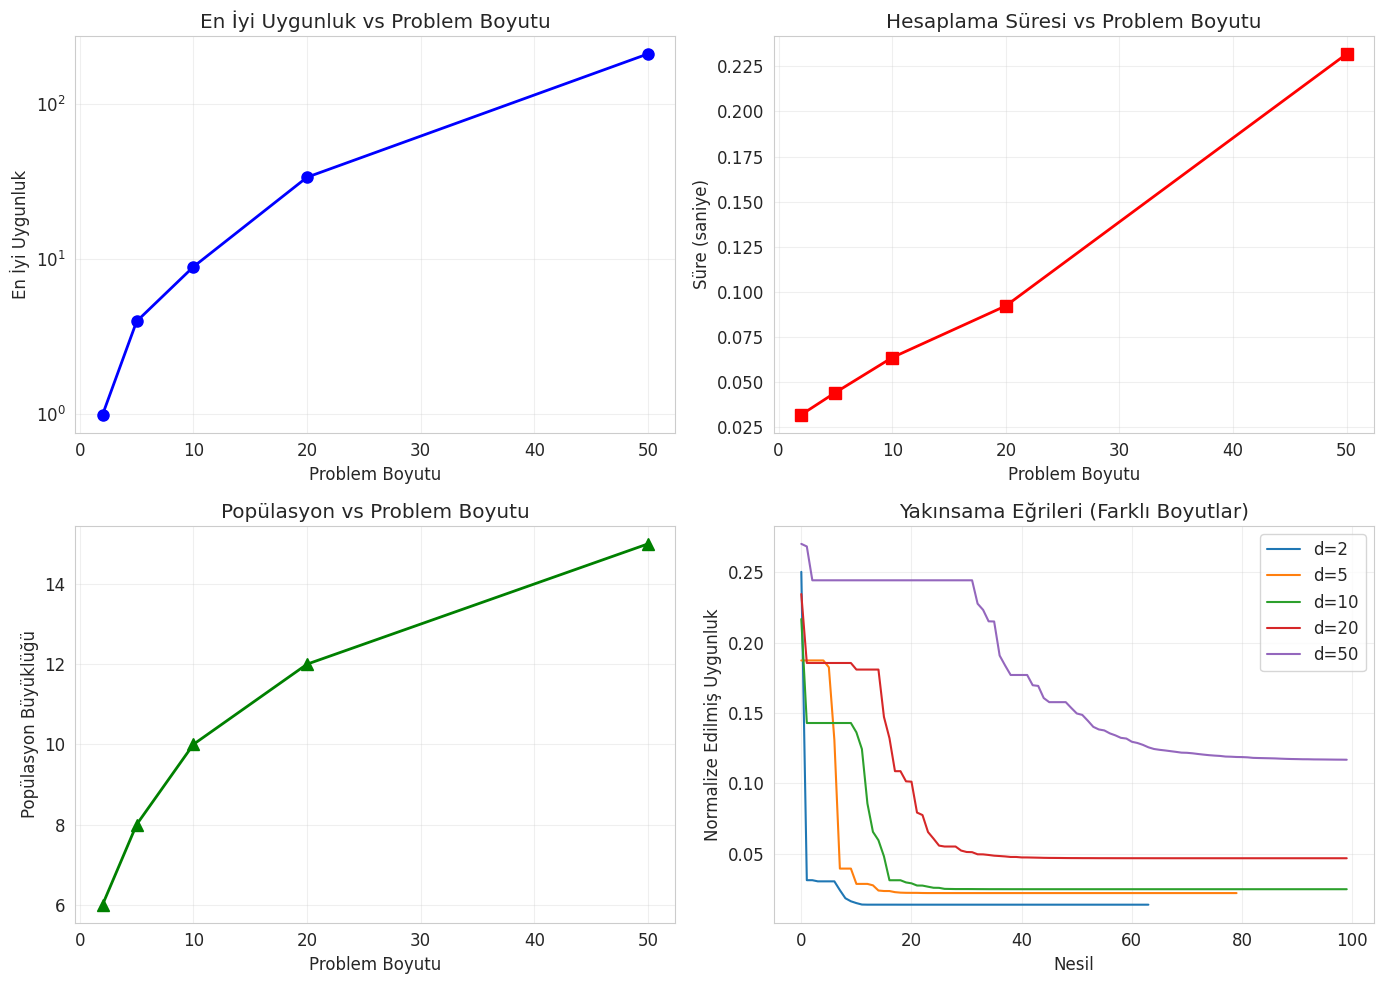


ÖZET TABLO:
 Boyut En İyi Uygunluk  Nesil  Popülasyon Süre (sn)
     2          0.9950     64           6      0.03
     5          3.9798     80           8      0.04
    10          8.9547    100          10      0.06
    20         33.8449    100          12      0.09
    50        211.3541    100          15      0.23


In [8]:
# Boyut ölçeklenebilirlik testi
# Farklı boyutlarda Rastrigin fonksiyonu üzerinde test

def rastrigin(x):
    """Rastrigin fonksiyonu - çok modlu test fonksiyonu."""
    n = len(x)
    return 10 * n + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))

dimensions = [2, 5, 10, 20, 50]
results = {}

for dim in dimensions:
    print(f'\nBoyut {dim} test ediliyor...')

    cmaes_test = CMAES(
        fitness_func=rastrigin,
        dim=dim,
        bounds=(-5.12, 5.12),
        sigma0=1.0,
        pop_size=None,  # Otomatik
        max_generations=100,
        verbose=False,
        seed=42
    )

    start = time.time()
    best_sol, best_fit = cmaes_test.optimize()
    elapsed = time.time() - start

    results[dim] = {
        'best_fitness': best_fit,
        'generations': len(cmaes_test.history['best_fitness']),
        'time': elapsed,
        'pop_size': cmaes_test.pop_size,
        'convergence': cmaes_test.history['best_fitness']
    }

    print(f'  En iyi uygunluk: {best_fit:.4f}')
    print(f'  Popülasyon: {cmaes_test.pop_size}')
    print(f'  Süre: {elapsed:.2f}s')

# Sonuçları görselleştir
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. En iyi uygunluk vs boyut
dims = list(results.keys())
fits = [results[d]['best_fitness'] for d in dims]
axes[0, 0].plot(dims, fits, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Problem Boyutu')
axes[0, 0].set_ylabel('En İyi Uygunluk')
axes[0, 0].set_title('En İyi Uygunluk vs Problem Boyutu')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_yscale('log')

# 2. Süre vs boyut
times = [results[d]['time'] for d in dims]
axes[0, 1].plot(dims, times, 'rs-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Problem Boyutu')
axes[0, 1].set_ylabel('Süre (saniye)')
axes[0, 1].set_title('Hesaplama Süresi vs Problem Boyutu')
axes[0, 1].grid(True, alpha=0.3)

# 3. Popülasyon büyüklüğü vs boyut
pops = [results[d]['pop_size'] for d in dims]
axes[1, 0].plot(dims, pops, 'g^-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Problem Boyutu')
axes[1, 0].set_ylabel('Popülasyon Büyüklüğü')
axes[1, 0].set_title('Popülasyon vs Problem Boyutu')
axes[1, 0].grid(True, alpha=0.3)

# 4. Yakınsama eğrileri ( normalize edilmiş)
for dim in dimensions:
    conv = np.array(results[dim]['convergence'])
    conv_norm = conv / (10 * dim + dim * 5.12**2)  # Teorik maksimuma göre normalize
    axes[1, 1].plot(conv_norm, label=f'd={dim}', linewidth=1.5)

axes[1, 1].set_xlabel('Nesil')
axes[1, 1].set_ylabel('Normalize Edilmiş Uygunluk')
axes[1, 1].set_title('Yakınsama Eğrileri (Farklı Boyutlar)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Özet tablo
summary = pd.DataFrame({
    'Boyut': dims,
    'En İyi Uygunluk': [f'{results[d]["best_fitness"]:.4f}' for d in dims],
    'Nesil': [results[d]['generations'] for d in dims],
    'Popülasyon': pops,
    'Süre (sn)': [f'{results[d]["time"]:.2f}' for d in dims]
})
print('\nÖZET TABLO:')
print(summary.to_string(index=False))

## 9. Sonuç

Bu notebook'ta **CMA-ES** algoritması sıfırdan implemente edilmiş ve **SVM hiperparametre optimizasyonu** problemine uygulanmıştır.

### Elde Edilen Sonuçlar:

1. **CMA-ES Implementasyonu:** Cholesky örnekleme, CSA ve rank-1/rank-μ kovaryans güncellemeleri başarıyla gerçekleştirilmiştir.

2. **Hiperparametre Optimizasyonu:** SVM'nin `C` ve `gamma` parametreleri otomatik olarak optimize edilmiştir.

3. **GridSearch Karşılaştırması:** CMA-ES, GridSearch ile benzer veya daha iyi sonuçlar verirken, parametrik arama yapmıştır.

4. **Boyut Ölçeklenebilirlik:** CMA-ES'in farklı boyutlardaki problemlerde performansı test edilmiştir.

### CMA-ES'in Güçlü Yönleri:

- Yüksek boyutlu problemlerde etkili
- Türev gerektirmez
- Zorlu, çok modlu fonksiyonlarda başarılıdır
- Otomatik adım boyutu ve yön adaptasyonu

### Gelecek Çalışmalar:

- Daha fazla hiperparametre (kernel tipi, degree) eklenmesi
- Farklı sınıflandırıcılarla test edilmesi
- Paralel değerlendirme ile hızlandırılması
- Büyük veri setleri için örnekleme stratejileri